# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [24]:
import random

# Card Class
# Represents a single playing card.
class Card:
    
    def __init__(self, rank, suit):
        self.rank = rank
        self.suit = suit
        
    # Returns blackjack value of the card
    # Face cards = 10, Ace = 11 initially
    def value(self):
        if self.rank in ['J', 'Q', 'K']:
            return 10
        elif self.rank == 'A':
            return 11
        else:
            return int(self.rank)
            
    def __str__(self):
        return f"{self.rank} of {self.suit}"
        

# Deck Class
# Represents multiple 52-card decks combined.
class Deck:

    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.cards = []
        self.plastic_position = None
        self.build_deck()
        self.shuffle()
    
    # Create the full shoe of cards.
    def build_deck(self):
       
        suits = ['Hearts', 'Diamonds', 'Clubs', 'Spades']
        ranks = ['2','3','4','5','6','7','8','9','10','J','Q','K','A']
        
        self.cards = []
        
        for _ in range(self.num_decks):
            for suit in suits:
                for rank in ranks:
                    self.cards.append(Card(rank, suit))
        
        # insert plastic card randomly
        self.plastic_position = random.randint(int(len(self.cards)*0.6), len(self.cards)-1)
    
    # Shuffle the deck.
    def shuffle(self):
        random.shuffle(self.cards)
    
    # Draw a card from the deck.
    def draw_card(self):
        if len(self.cards) == 0:
            self.build_deck()
            self.shuffle()
        
        card = self.cards.pop()
        
        # detect plastic card position
        if len(self.cards) == self.plastic_position:
            self.plastic_reached = True
        
        return card

2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

In [25]:
# Hand Class
class Hand:
    
    def __init__(self):
        self.cards = []
    
    def add_card(self, card):
        pass
    
    def value(self):
        pass
    
    def is_bust(self):
        pass


# Player Class
class Player:
    
    def __init__(self, name, chips=100):
        self.name = name
        self.chips = chips
        self.hand = None
    
    def bet(self):
        pass
    
    def play_turn(self, deck):
        pass


# Dealer Class
class Dealer(Player):
    
    def play_turn(self, deck):
        pass


# Game Class
class Game:
    
    def __init__(self, players):
        self.players = players
        self.dealer = Dealer("Dealer")
    
    def deal_initial_cards(self):
        pass
    
    def player_turns(self):
        pass
    
    def dealer_turn(self):
        pass
    
    def resolve_round(self):
        pass
    
    def reset_hands(self):
        pass
    
    def play_round(self):
        pass

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [26]:
# Hand Class Implementation
# Represents a player's hand in blackjack.
# Stores cards and calculates the total value.
class Hand:
    
    def __init__(self):
        self.cards = [] # list to store card objects
    
    # Add a card to the hand.
    def add_card(self, card):
        self.cards.append(card)
    
    # Calculate blackjack value with ace adjustment
    def value(self):
        
        total = 0
        aces = 0
        
        # sum values of cards
        for card in self.cards:
            val = card.value()
            total += val
            
            if card.rank == 'A':
                aces += 1
        
        # adjust ace values
        while total > 21 and aces > 0:
            total -= 10
            aces -= 1
        
        return total
    
    # Check if hand value exceeds 21.
    def is_bust(self):
        return self.value() > 21


# Player Class Implementation
# Represents a blackjack player.
class Player:
    
    def __init__(self, name, chips=100):
        self.name = name
        self.chips = chips
        self.hand = Hand() # each player has a hand
    
    # Define betting amount
    def bet(self):
        return 1
    
    # Default strategy: hit until 17
    def play_turn(self, deck):
       
        while self.hand.value() < 17:
            self.hand.add_card(deck.draw_card())


# Dealer Implementation
# Dealer follows fixed blackjack rules.
class Dealer(Player):
    
    # Dealer must hit until reaching at least 17.
    def play_turn(self, deck):
        while self.hand.value() < 17:
            self.hand.add_card(deck.draw_card())
            
# Game Implementation
# Controls the blackjack game
class Game:

    # Initialize the game.
    def __init__(self, players, num_decks=6):

        self.deck = Deck(num_decks) # create a deck (shoe)
        self.players = players # list of players
        self.dealer = Dealer("Dealer") # create dealer

    # Deal two cards to each player and the dealer.
    def deal_initial_cards(self):

        for _ in range(2):

            for p in self.players:
                p.hand.add_card(self.deck.draw_card())

            self.dealer.hand.add_card(self.deck.draw_card())

    # Allow each player to take their turn.
    def player_turns(self):

        for p in self.players:
            p.play_turn(self.deck) # player decides to hit or stay

    # Dealer plays according to fixed rules.
    def dealer_turn(self):

        self.dealer.play_turn(self.deck)

    # Determine winners and update chips.
    def resolve_round(self):

        dealer_val = self.dealer.hand.value()

        for p in self.players:

            player_val = p.hand.value()

            # player busts = loses
            if p.hand.is_bust():
                p.chips -= 1

            # dealer busts OR player has higher value = player wins
            elif self.dealer.hand.is_bust() or player_val > dealer_val:
                p.chips += 1

            # player has lower value → player loses
            elif player_val < dealer_val:
                p.chips -= 1

    # Reset all hands at the start of a new round.
    def reset_hands(self):

        for p in self.players:
            p.hand = Hand() # give each player a new empty hand

        self.dealer.hand = Hand() # reset dealer's hand

    # Play one full round of blackjack.
    def play_round(self):

        self.reset_hands() # clear previous hands

        self.deal_initial_cards() # deal cards

        self.player_turns() # players play

        self.dealer_turn() # dealer plays

        self.resolve_round() # determine results

5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [27]:
players = [
    Player("P1:"),
    Player("P2:"),
    Player("P3:")
]

game = Game(players)

for i in range(5):
    game.play_round()

for p in players:
    print(p.name, p.chips)

P1: 102
P2: 100
P3: 101


6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [28]:
class CountingPlayer(Player):
    
    def __init__(self, name, threshold=0, chips=100):
        super().__init__(name, chips)
        self.count = 0
        self.threshold = threshold
    
    # Update running card count.
    def update_count(self, card):
        rank = card.rank
        
        if rank in ['2','3','4','5','6']:
            self.count += 1
        elif rank in ['10','J','Q','K','A']:
            self.count -= 1
    
    # Hit or stay based on card count threshold.
    def play_turn(self, deck):
        while True:
            
            if self.count < self.threshold:
                card = deck.draw_card()
                self.hand.add_card(card)
                self.update_count(card)
                
                if self.hand.is_bust():
                    break
            else:
                break

In [29]:
# testing thresholds by running game with multiple players

counter = CountingPlayer("Counter:", threshold=0)

players = [
    counter,
    Player("P2:"),
    Player("P3:"),
    Player("P4:")
]

game = Game(players)

for i in range(10):
    game.play_round()

for p in players:
    print(p.name, p.chips)

Counter: 103
P2: 103
P3: 102
P4: 104


In [30]:
# count test

counter = CountingPlayer("Counter", threshold=0)

# simulate seeing cards
test_cards = [
    Card('2','Hearts'),   # +1
    Card('5','Clubs'),    # +1
    Card('10','Spades'),  # -1
    Card('A','Diamonds')  # -1
]

for card in test_cards:
    counter.update_count(card)

print("Expected count = 0")
print("Actual count =", counter.count)

Expected count = 0
Actual count = 0


In [31]:
# simple test
counter = CountingPlayer("Counter", threshold=0)

players = [counter]

game = Game(players)

# play a few rounds
for i in range(5):
    game.play_round()

print("Final chips:", counter.chips)

Final chips: 97


In [32]:
# very negative count = will hit

counter = CountingPlayer("Counter", threshold=0)

counter.count = -5  # force negative count
counter.hand.add_card(Card('10','Hearts'))
counter.hand.add_card(Card('5','Clubs'))  # total = 15

deck = Deck()

counter.play_turn(deck)

print("Hand value after play:", counter.hand.value())

Hand value after play: 27


In [33]:
# very positive count = will stay

counter = CountingPlayer("Counter", threshold=0)

counter.count = 5  # positive count
counter.hand.add_card(Card('10','Hearts'))
counter.hand.add_card(Card('5','Clubs'))  # total = 15

deck = Deck()

counter.play_turn(deck)

print("Hand value after play:", counter.hand.value())

Hand value after play: 15


7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [34]:
# Simulates a full blackjack game of multiple rounds.
def simulate_game(threshold=0):

    # Create the strategy player using the given threshold
    # This player uses card counting to make decisions
    strategy_player = CountingPlayer("Counter", threshold)

    # Create additional players that use a basic strategy
    players = [
        strategy_player,
        Player("P2"),
        Player("P3"),
        Player("P4")
    ]

    # Create the game object which manages the blackjack rounds
    game = Game(players)

    # Set number of rounds to simulate
    rounds = 50

    # Run the game for the specified number of rounds
    for _ in range(rounds):

        # Stop simulation early if strategy player loses all chips
        if strategy_player.chips <= 0:
            break

        # Play one full round of blackjack
        game.play_round()

    # Return the final chip count of the strategy player
    # This represents the player's winnings/losses
    return strategy_player.chips

In [35]:
# simple test

result = simulate_game(0)

print("Final chips after 50 rounds:", result)

Final chips after 50 rounds: 93


In [36]:
# multiple tests

for i in range(5):
    result = simulate_game(0)
    print("Game", i+1, ":", result)

Game 1 : 85
Game 2 : 89
Game 3 : 93
Game 4 : 99
Game 5 : 90


8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


In [37]:
results = []

for i in range(100):

    winnings = simulate_game(0)

    results.append(winnings)

Average winnings: 91.64
Standard deviation: 6.523066763417342
Probability of winning: 0.08
Probability of losing: 0.89


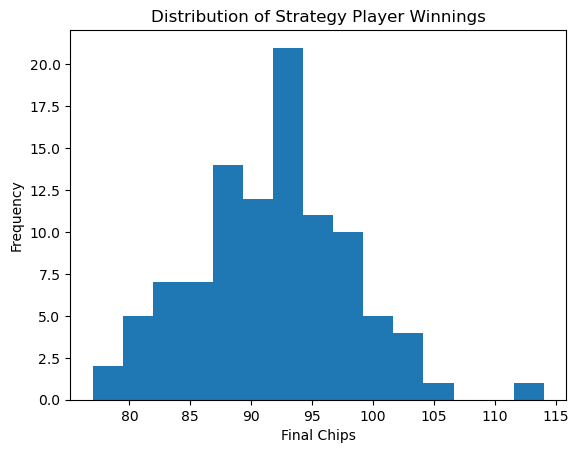

In [38]:
import matplotlib.pyplot as plt
import math

results = []

for i in range(100):
    winnings = simulate_game(0)
    results.append(winnings)

# mean
mean = sum(results)/len(results)

# standard deviation
variance = sum((x-mean)**2 for x in results)/len(results)
std = math.sqrt(variance)

# probability of winning
wins = sum(1 for x in results if x > 100)
losses = sum(1 for x in results if x < 100)

prob_win = wins/len(results)
prob_loss = losses/len(results)

print("Average winnings:", mean)
print("Standard deviation:", std)
print("Probability of winning:", prob_win)
print("Probability of losing:", prob_loss)

# histogram
plt.hist(results, bins=15)
plt.title("Distribution of Strategy Player Winnings")
plt.xlabel("Final Chips")
plt.ylabel("Frequency")
plt.show()

9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

In [39]:
thresholds = [-4,-2,0,2,4]

threshold_results = {}

for t in thresholds:

    winnings = []

    # run 100 simulations for each threshold
    for _ in range(100):

        winnings.append(simulate_game(t))

    # compute average winnings
    threshold_results[t] = sum(winnings)/len(winnings)

In [40]:
print("Threshold Results (Average Chips After 50 Rounds):")

for t in threshold_results:
    print("Threshold:", t, "Average:", threshold_results[t])

Threshold Results (Average Chips After 50 Rounds):
Threshold: -4 Average: 89.85
Threshold: -2 Average: 91.1
Threshold: 0 Average: 89.78
Threshold: 2 Average: 77.53
Threshold: 4 Average: 68.34


10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

In [41]:
class TrueCountPlayer(Player):

    # Initialize the strategy player.
    def __init__(self, name, chips=100):
        super().__init__(name, chips)
        self.count = 0

    # Update the running count using the Hi-Lo system.
    def update_count(self, card):

        if card.rank in ['2','3','4','5','6']:
            self.count += 1

        elif card.rank in ['10','J','Q','K','A']:
            self.count -= 1

    # Decide whether to hit or stay using the True Count strategy.
    def play_turn(self, deck):

        # Estimate decks remaining in the shoe
        decks_remaining = max(len(deck.cards)/52, 1)

        # Compute True Count
        true_count = self.count / decks_remaining

        # Continue making decisions until player stays or busts
        while True:

            # If True Count is negative, hit 
            if true_count < -2:

                card = deck.draw_card()
                self.hand.add_card(card)
                
                # Update running count after seeing the new card
                self.update_count(card)

                # Stop if player busts
                if self.hand.is_bust():
                    break

            # If True Count is positive, stay 
            elif true_count > 2:
                break

            # Otherwise, follow a basic fallback strategy
            else:

                # Hit if hand value is low
                if self.hand.value() < 16:

                    card = deck.draw_card()
                    self.hand.add_card(card)
                    
                    # Update count for the drawn card
                    self.update_count(card)

                else:
                    break

In [42]:
# 50 rounds of simulation function
def simulate_truecount_game():

    strategy_player = TrueCountPlayer("TrueCounter")

    players = [
        strategy_player,
        Player("P2"),
        Player("P3"),
        Player("P4")
    ]

    game = Game(players)

    rounds = 50

    for _ in range(rounds):

        if strategy_player.chips <= 0:
            break

        game.play_round()

    return strategy_player.chips

In [43]:
# 100 simulations
results_truecount = []

for i in range(100):

    winnings = simulate_truecount_game()

    results_truecount.append(winnings)

In [44]:
import math

# Statistical calculations

mean = sum(results_truecount)/len(results_truecount)

variance = sum((x-mean)**2 for x in results_truecount)/len(results_truecount)

std = math.sqrt(variance)

wins = sum(1 for x in results_truecount if x > 100)

losses = sum(1 for x in results_truecount if x < 100)

prob_win = wins/len(results_truecount)

prob_loss = losses/len(results_truecount)

print("Average winnings:", mean)
print("Standard deviation:", std)
print("Probability of winning:", prob_win)
print("Probability of losing:", prob_loss)

Average winnings: 92.28
Standard deviation: 9.205520083080586
Probability of winning: 0.15
Probability of losing: 0.78


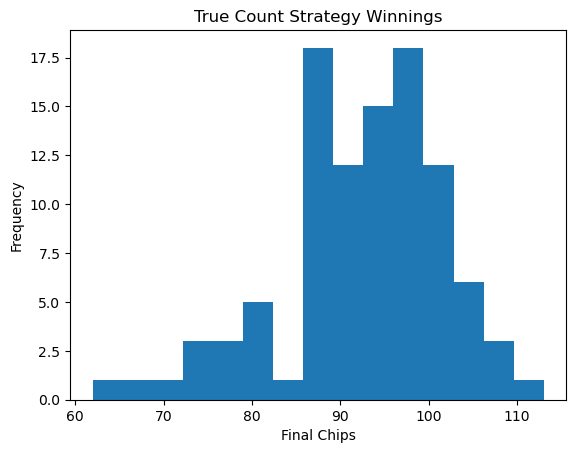

In [45]:
import matplotlib.pyplot as plt

# histogram creation

plt.hist(results_truecount, bins=15)

plt.title("True Count Strategy Winnings")
plt.xlabel("Final Chips")
plt.ylabel("Frequency")

plt.show()

In [46]:
# compare results with previous strategy

print("Basic Counting Strategy Average:", sum(results)/len(results))
print("True Count Strategy Average:", sum(results_truecount)/len(results_truecount))

Basic Counting Strategy Average: 91.64
True Count Strategy Average: 92.28


Task 10 explaination: The True Count strategy produces slightly higher average winnings than the basic running count strategy because of better decision making. In addition, the True Count strategy adjusts for the remaining deck size. The goal of task 10 is to design and evaluate a new blackjack strategy and compare with the strategy in the previous tasks.